#k-Nearest Neighbours



In [ ]:
import os, sys, shutil
from google.colab import drive
drive.mount('/content/drive')

FOLDER = "/content/drive/MyDrive/GrainWise_Member_4"

if not os.path.isdir(FOLDER):
    print("Folder not found:", FOLDER)
    print("\nFolders in your MyDrive:")
    for d in sorted(os.listdir("/content/drive/MyDrive")):
        print("   ", d)
    raise SystemExit("Fix FOLDER above, then re-run this cell.")

print("Files in that folder:", os.listdir(FOLDER))

shutil.copy(f"{FOLDER}/rice_shared.py", "/content/rice_shared.py")
sys.path.insert(0, "/content")

import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import rice_shared as rs
from sklearn.model_selection import GridSearchCV
sns.set_theme(style="whitegrid")

rs.DATA_PATH = f"{FOLDER}/Rice_Cammeo_Osmancik.arff"
X_train, X_test, y_train, y_test = rs.get_split("all")

print("\nTrain:", X_train.shape, " Test:", X_test.shape)
print("Train balance:", round(y_train.mean(), 4))
print("\nMUST read (3048, 10) and 0.4278 - if not, stop and tell Member 1.")

Mounted at /content/drive
Files in that folder: ['rice_shared.py', 'Rice_Cammeo_Osmancik.arff']

Train: (3048, 10)  Test: (762, 10)
Train balance: 0.4278

MUST read (3048, 10) and 0.4278 - if not, stop and tell Member 1.


## Tuning
**k-NN must be scaled** — `scale=True`. It is a pure distance method, so an unscaled `Area` in the tens of thousands drowns out everything else.



In [ ]:
from sklearn.neighbors import KNeighborsClassifier

grid = {"model__n_neighbors": [3, 5, 9, 15, 25],
        "model__weights": ["uniform", "distance"],
        "model__p": [1, 2]}

gs = GridSearchCV(rs.make_pipeline(KNeighborsClassifier(), scale=True),
                  grid, cv=rs.INNER_CV, scoring="roc_auc", n_jobs=-1)
gs.fit(X_train, y_train)

print("Best params:", gs.best_params_)
print(f"Inner-CV ROC-AUC: {gs.best_score_:.4f}   <- tuning score, NOT reported")

Best params: {'model__n_neighbors': 25, 'model__p': 2, 'model__weights': 'distance'}
Inner-CV ROC-AUC: 0.9766   <- tuning score, NOT reported


## Reported performance
Repeated stratified CV, 10 splits × 3 repeats. This is the number that goes in the
comparison table.

In [ ]:
best = gs.best_estimator_.named_steps["model"]

row, res = rs.score(best, X_train, y_train, name="k-Nearest Neighbours", scale=True)
display(pd.DataFrame([{k: v for k, v in row.items()
                       if k.endswith(("_mean", "_std")) or k == "model"}]).round(4).T)

,0
model,k-Nearest Neighbours
accuracy_mean,0.928
accuracy_std,0.0117
balanced_accuracy_mean,0.9266
balanced_accuracy_std,0.0125
precision_mean,0.9154
precision_std,0.0168
recall_mean,0.9169
recall_std,0.0229
f1_mean,0.9159


In [ ]:
import os
os.makedirs(f"{FOLDER}/results", exist_ok=True)
rs.save_results(row, res, "results_knn.csv")
shutil.copy("results_knn.csv",       f"{FOLDER}/results/")
shutil.copy("results_knn_folds.npy", f"{FOLDER}/results/")
print("\nSaved to", f"{FOLDER}/results/")

saved: results_knn.csv

Saved to /content/drive/MyDrive/GrainWise_Member_4/results/


### Seed stability
Does the result survive a different partition? Cheap, and the rubric rewards it.

In [ ]:
for seed in [42, 7, 2024]:
    Xtr, _, ytr, _ = rs.get_split("all", seed=seed)
    r, _ = rs.score(best, Xtr, ytr, name=f"seed={seed}", scale=True)
    print(f"seed {seed}: acc {r['accuracy_mean']:.4f} ± {r['accuracy_std']:.4f} | "
          f"AUC {r['roc_auc_mean']:.4f}")

seed 42: acc 0.9280 ± 0.0117 | AUC 0.9759
seed 7: acc 0.9277 ± 0.0143 | AUC 0.9763
seed 2024: acc 0.9298 ± 0.0109 | AUC 0.9765


## How many neighbours, and does distance weighting help?
k-NN has no importance measure of its own — it is the least interpretable model in the
comparison, which is a legitimate column in the comparison table. What it *can* show is
how sensitive the result is to k.

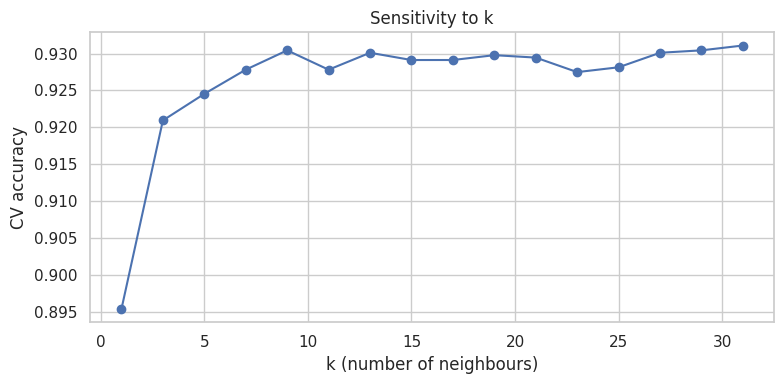

Best k on this sweep: 31


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

ks, accs = list(range(1, 32, 2)), []
for k in ks:
    r, _ = rs.score(KNeighborsClassifier(n_neighbors=k), X_train, y_train,
                    name=f"k={k}", scale=True,
                    cv=__import__("sklearn.model_selection", fromlist=["x"]
                                  ).StratifiedKFold(n_splits=5, shuffle=True,
                                                    random_state=42))
    accs.append(r["accuracy_mean"])

plt.figure(figsize=(8, 4))
plt.plot(ks, accs, marker="o")
plt.xlabel("k (number of neighbours)"); plt.ylabel("CV accuracy")
plt.title("Sensitivity to k"); plt.tight_layout(); plt.show()
print("Best k on this sweep:", ks[int(np.argmax(accs))])

### Why scaling matters most here
k-NN is the model that breaks loudest without scaling, because it compares raw
distances.

In [ ]:
r_scaled, _ = rs.score(best, X_train, y_train, name="scaled", scale=True)
r_raw, _ = rs.score(best, X_train, y_train, name="unscaled", scale=False)
print(f"scaled:   {r_scaled['accuracy_mean']:.4f}")
print(f"unscaled: {r_raw['accuracy_mean']:.4f}")
print(f"\nDifference: {100*(r_scaled['accuracy_mean']-r_raw['accuracy_mean']):.2f} points")
print("This is direct evidence for preprocessing decision P9 - scaling per model type.")

scaled:   0.9280
unscaled: 0.8887

Difference: 3.94 points
This is direct evidence for preprocessing decision P9 - scaling per model type.
